In [2]:
!pip install scikit-learn scipy tqdm --quiet
print("✅ Instalado")

✅ Instalado


In [3]:
import os, gc, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import wasserstein_distance
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FONTSCALE = 1.5
FS_TITLE = 13*FONTSCALE; FS_LABEL = 11*FONTSCALE
FS_TICK = 10*FONTSCALE; FS_STATS = 9*FONTSCALE
c_line = "#1a5276"

OUT_DIR = "/workspace/Process/Images"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs("/workspace/Process/metrics", exist_ok=True)

model_colors = {"Real": "#1f77b4", "CVAE": "#e67e22", "DDPM-Paper": "#59a14f", "DDPM-FiLM": "#9b59b6"}
structure_colors = {"helical": "#d62728", "Others": "#ff7f0e", "Bimerones": "#9467bd",
                    "Skyrmiones": "#2ca02c", "Ising": "#1f77b4"}
structure_labels = {"helical": "Helical", "Others": "Others", "Bimerones": "Bimerons",
                    "Skyrmiones": "Skyrmions", "Ising": "Ising"}
print(f"Device: {device}")

Device: cuda


In [4]:
DATASET_PATH = "/workspace/Preprocess/latent_space_outputs/dataset_final_estructuras.npz"

data = np.load(DATASET_PATH, allow_pickle=True)
imgs   = data["img"].astype(np.float32)
params = data["params"].astype(np.float32)
label_all = np.array([str(s) for s in data["label_names"]])

idx_all = np.arange(len(imgs))
X_tr, X_tmp, y_tr, y_tmp, i_tr, i_tmp = train_test_split(
    imgs, params, idx_all, test_size=0.30, random_state=SEED)
X_val, X_te, y_val, y_te, i_val, i_te = train_test_split(
    X_tmp, y_tmp, i_tmp, test_size=0.50, random_state=SEED)
label_test = label_all[i_te]

scaler = MinMaxScaler().fit(y_tr)
y_te_s = scaler.transform(y_te).astype(np.float32)

structures = [s for s in ["helical", "Others", "Bimerones", "Skyrmiones", "Ising"]
              if (label_test == s).sum() > 0]

IMG_SIZE = 40; COND_DIM = 8
print(f"Test: {X_te.shape[0]:,} | estructuras: {structures}")
for s in structures:
    print(f"  {s:<12} N={(label_test==s).sum()}")

Test: 24,922 | estructuras: ['helical', 'Others', 'Bimerones', 'Skyrmiones', 'Ising']
  helical      N=18122
  Others       N=3748
  Bimerones    N=966
  Skyrmiones   N=1875
  Ising        N=211


In [5]:
def metric_magnetization(imgs_39):
    """M = ⟨s⟩ por imagen. (N,39,39) → (N,)"""
    return imgs_39.reshape(len(imgs_39), -1).mean(axis=1)

def metric_abs_magnetization(imgs_39):
    """|M| = |⟨s⟩| por imagen."""
    return np.abs(metric_magnetization(imgs_39))

def metric_spin_correlation(imgs_39):
    """Correlación espín-espín a primeros vecinos: ⟨s_i·s_j⟩ (horizontal + vertical)."""
    h = (imgs_39[:, :, :-1] * imgs_39[:, :, 1:]).reshape(len(imgs_39), -1).mean(axis=1)
    v = (imgs_39[:, :-1, :] * imgs_39[:, 1:, :]).reshape(len(imgs_39), -1).mean(axis=1)
    return 0.5 * (h + v)

def metric_peak_wavevector(imgs_39):
    """k* = posición del pico del espectro de potencia radial (excluye DC).
    Captura el periodo dominante de los dominios."""
    N, H, W = imgs_39.shape
    win = np.outer(np.hanning(H), np.hanning(W))
    ks = np.zeros(N)
    cy, cx = H // 2, W // 2
    Y, X = np.ogrid[:H, :W]
    R = np.sqrt((X - cx)**2 + (Y - cy)**2).round().astype(int)
    kmax = min(H, W) // 2
    counts = np.bincount(R.ravel(), minlength=R.max()+1).astype(float)
    for i in range(N):
        x = imgs_39[i] - imgs_39[i].mean()
        P = np.abs(np.fft.fftshift(np.fft.fft2(x * win)))**2
        radial = np.bincount(R.ravel(), P.ravel(), minlength=R.max()+1) / np.maximum(counts, 1)
        radial[:2] = 0                        # excluir DC / freq casi nula
        ks[i] = radial[:kmax].argmax()
    return ks

METRICS = {
    "Magnetization":      metric_magnetization,
    "Abs. Magnetization": metric_abs_magnetization,
    "Spin Correlation":   metric_spin_correlation,
    "Peak Wavevector":    metric_peak_wavevector,
}
print("✅ 4 métricas definidas:", list(METRICS.keys()))

✅ 4 métricas definidas: ['Magnetization', 'Abs. Magnetization', 'Spin Correlation', 'Peak Wavevector']


In [6]:
# ═══ CVAE ═══
class CVAE(nn.Module):
    def __init__(self, z_dim=64, cond_dim=8, base_ch=32):
        super().__init__()
        self.z_dim = z_dim; self.base_ch = base_ch
        self.enc = nn.Sequential(
            nn.Conv2d(1, base_ch, 4, 2, 1), nn.BatchNorm2d(base_ch), nn.SiLU(),
            nn.Conv2d(base_ch, base_ch*2, 4, 2, 1), nn.BatchNorm2d(base_ch*2), nn.SiLU(),
            nn.Conv2d(base_ch*2, base_ch*4, 4, 2, 1), nn.BatchNorm2d(base_ch*4), nn.SiLU())
        self.enc_out_dim = base_ch*4*5*5
        self.cond_mlp = nn.Sequential(nn.Linear(cond_dim, 64), nn.SiLU(), nn.Linear(64, 64), nn.SiLU())
        self.fc_mu = nn.Linear(self.enc_out_dim+64, z_dim)
        self.fc_logvar = nn.Linear(self.enc_out_dim+64, z_dim)
        self.prior_mu = nn.Linear(64, z_dim); self.prior_logvar = nn.Linear(64, z_dim)
        self.dec_fc = nn.Linear(z_dim+64, base_ch*4*5*5)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, 2, 1), nn.BatchNorm2d(base_ch*2), nn.SiLU(),
            nn.ConvTranspose2d(base_ch*2, base_ch, 4, 2, 1), nn.BatchNorm2d(base_ch), nn.SiLU(),
            nn.ConvTranspose2d(base_ch, 1, 4, 2, 1), nn.Tanh())
    def reparam(self, mu, lv): return mu + torch.exp(0.5*lv)*torch.randn_like(mu)
    def decode(self, z, c):
        h = self.dec_fc(torch.cat([z, c], dim=1))
        return self.dec(h.view(-1, self.base_ch*4, 5, 5))
    @torch.no_grad()
    def sample(self, y):
        c = self.cond_mlp(y)
        return self.decode(self.reparam(self.prior_mu(c), self.prior_logvar(c)), c)

# ═══ Scheduler + embeddings ═══
class DDPMScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device="cuda"):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

def sinusoidal_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
    args = t[:, None].float() * freqs[None]
    return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

# ═══ DDPM Paper (suma) ═══
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch); self.norm2 = nn.GroupNorm(8, out_ch)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = F.silu(self.norm1(self.conv1(x)))
        h = h + self.emb_proj(emb)[:, :, None, None]
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)

class UNetDDPM(nn.Module):
    def __init__(self, cond_dim=8, base_ch=64, emb_dim=256):
        super().__init__()
        self.emb_dim = emb_dim
        self.time_mlp = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.cond_mlp = nn.Sequential(nn.Linear(cond_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.in_conv = nn.Conv2d(1, base_ch, 3, padding=1)
        self.down1 = ResBlock(base_ch, base_ch, emb_dim)
        self.down2 = ResBlock(base_ch, base_ch*2, emb_dim)
        self.pool = nn.AvgPool2d(2)
        self.mid = ResBlock(base_ch*2, base_ch*2, emb_dim)
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.up1 = ResBlock(base_ch*2+base_ch*2, base_ch, emb_dim)
        self.up2 = ResBlock(base_ch+base_ch, base_ch, emb_dim)
        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)
    def forward(self, x, t, cond):
        emb = self.time_mlp(sinusoidal_embedding(t, self.emb_dim)) + self.cond_mlp(cond)
        x = self.in_conv(x)
        d1 = self.down1(x, emb); d2 = self.down2(self.pool(d1), emb)
        m = self.mid(d2, emb)
        u = self.up1(torch.cat([m, d2], 1), emb)
        u = self.up(u)
        u = self.up2(torch.cat([u, d1], 1), emb)
        return self.out_conv(u)

# ═══ DDPM FiLM ═══
class FiLMResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, cond_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch); self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_proj = nn.Linear(time_dim, out_ch)
        self.film = nn.Linear(cond_dim, 2*out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb, c_emb):
        h = self.conv1(x)
        h = self.norm1(h) + self.time_proj(t_emb)[:, :, None, None]
        gamma, beta = self.film(c_emb).chunk(2, dim=1)
        h = gamma[:, :, None, None]*h + beta[:, :, None, None]
        h = F.silu(h)
        h = F.silu(self.norm2(self.conv2(h)))
        return h + self.skip(x)

class UNetFiLM(nn.Module):
    def __init__(self, cond_dim=8, base_ch=64, emb_dim=256):
        super().__init__()
        self.emb_dim = emb_dim
        self.time_mlp = nn.Sequential(nn.Linear(emb_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.cond_mlp = nn.Sequential(nn.Linear(cond_dim, emb_dim), nn.SiLU(), nn.Linear(emb_dim, emb_dim))
        self.in_conv = nn.Conv2d(1, base_ch, 3, padding=1)
        self.down1 = FiLMResBlock(base_ch, base_ch, emb_dim, emb_dim)
        self.down2 = FiLMResBlock(base_ch, base_ch*2, emb_dim, emb_dim)
        self.pool = nn.AvgPool2d(2)
        self.mid = FiLMResBlock(base_ch*2, base_ch*2, emb_dim, emb_dim)
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        self.up1 = FiLMResBlock(base_ch*2+base_ch*2, base_ch, emb_dim, emb_dim)
        self.up2 = FiLMResBlock(base_ch+base_ch, base_ch, emb_dim, emb_dim)
        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)
    def forward(self, x, t, cond):
        t_emb = self.time_mlp(sinusoidal_embedding(t, self.emb_dim))
        c_emb = self.cond_mlp(cond)
        x = self.in_conv(x)
        d1 = self.down1(x, t_emb, c_emb); d2 = self.down2(self.pool(d1), t_emb, c_emb)
        m = self.mid(d2, t_emb, c_emb)
        u = self.up1(torch.cat([m, d2], 1), t_emb, c_emb)
        u = self.up(u)
        u = self.up2(torch.cat([u, d1], 1), t_emb, c_emb)
        return self.out_conv(u)

# ═══ Sampling DDIM (compartido por los dos DDPM) ═══
@torch.no_grad()
def sample_ddim(model, cond, scheduler, n_steps=50, eta=0.0):
    model.eval()
    B = cond.size(0)
    step_idx = torch.linspace(0, scheduler.T-1, n_steps, dtype=torch.long).flip(0)
    x = torch.randn(B, 1, IMG_SIZE, IMG_SIZE, device=cond.device)
    with torch.amp.autocast('cuda'):
        for i in range(n_steps):
            t = step_idx[i]
            t_b = torch.full((B,), t, device=cond.device, dtype=torch.long)
            eps = model(x, t_b, cond)
            ab_t = scheduler.alpha_bars[t]
            x0 = ((x - torch.sqrt(1-ab_t)*eps) / torch.sqrt(ab_t)).clamp(-1, 1)
            if i < n_steps - 1:
                ab_n = scheduler.alpha_bars[step_idx[i+1]]
                x = torch.sqrt(ab_n)*x0 + torch.sqrt(1-ab_n)*eps
            else:
                x = x0
    return x

scheduler = DDPMScheduler(T=1000, device=device)
print("✅ Arquitecturas + scheduler + DDIM definidos")

✅ Arquitecturas + scheduler + DDIM definidos


In [7]:
MODELS = {}

cvae = CVAE(z_dim=64, cond_dim=8).to(device)
cvae.load_state_dict(torch.load("/workspace/Models/cvae_physical_8params.pth"))
cvae.eval(); MODELS["CVAE"] = cvae

ddpm_p = UNetDDPM(cond_dim=8).to(device)
ddpm_p.load_state_dict(torch.load("/workspace/Models/ddpm_paper_8params_ema.pth"))
ddpm_p.eval(); MODELS["DDPM-Paper"] = ddpm_p

ddpm_f = UNetFiLM(cond_dim=8).to(device)
ddpm_f.load_state_dict(torch.load("/workspace/Models/ddpm_film_8params_ema.pth"))
ddpm_f.eval(); MODELS["DDPM-FiLM"] = ddpm_f

for name, m in MODELS.items():
    print(f"  ✅ {name:<12} {sum(p.numel() for p in m.parameters()):,} parámetros")

  ✅ CVAE         1,173,441 parámetros
  ✅ DDPM-Paper   1,236,481 parámetros
  ✅ DDPM-FiLM    1,466,753 parámetros


In [8]:
N_PER_STRUCT = 300        # muestras por estructura
DDIM_STEPS   = 50

def generate_with(model_name, cond_batch):
    """Genera imágenes 39×39 condicionadas en cond_batch (escalado [0,1])."""
    model = MODELS[model_name]
    if model_name == "CVAE":
        with torch.no_grad():
            out = model.sample(cond_batch)
    else:
        out = sample_ddim(model, cond_batch, scheduler, n_steps=DDIM_STEPS)
    return out[:, 0, :39, :39].float().cpu().numpy()

real_by_struct = {}
gen_by_struct  = {m: {} for m in MODELS}
rng = np.random.default_rng(SEED)

for s in structures:
    idx_s = np.where(label_test == s)[0]
    sel = rng.choice(idx_s, min(N_PER_STRUCT, len(idx_s)), replace=False)
    real_by_struct[s] = X_te[sel][:, :, :, 0]                      # (n,39,39)
    cond = torch.from_numpy(y_te_s[sel]).float().to(device)

    for mname in MODELS:
        t0 = time.time()
        gen_by_struct[mname][s] = generate_with(mname, cond)
        print(f"  {mname:<12} {s:<12} {len(sel)} imgs en {time.time()-t0:.1f}s")

print("✅ Generación completa")

  CVAE         helical      300 imgs en 0.3s
  DDPM-Paper   helical      300 imgs en 0.6s
  DDPM-FiLM    helical      300 imgs en 0.4s
  CVAE         Others       300 imgs en 0.0s
  DDPM-Paper   Others       300 imgs en 0.3s
  DDPM-FiLM    Others       300 imgs en 0.4s
  CVAE         Bimerones    300 imgs en 0.0s
  DDPM-Paper   Bimerones    300 imgs en 0.3s
  DDPM-FiLM    Bimerones    300 imgs en 0.4s
  CVAE         Skyrmiones   300 imgs en 0.0s
  DDPM-Paper   Skyrmiones   300 imgs en 0.3s
  DDPM-FiLM    Skyrmiones   300 imgs en 0.4s
  CVAE         Ising        211 imgs en 0.0s
  DDPM-Paper   Ising        211 imgs en 0.3s
  DDPM-FiLM    Ising        211 imgs en 0.3s
✅ Generación completa


In [9]:
# vals[metric][source][struct] = array de valores por imagen
vals = {mt: {src: {} for src in ["Real"] + list(MODELS)} for mt in METRICS}

for s in structures:
    for mt, fn in METRICS.items():
        vals[mt]["Real"][s] = fn(real_by_struct[s])
        for mname in MODELS:
            vals[mt][mname][s] = fn(np.clip(gen_by_struct[mname][s], -1, 1))

# tabla resumen: distancia de Wasserstein real vs generado (global y por estructura)
rows = []
for mt in METRICS:
    for mname in MODELS:
        r_all = np.concatenate([vals[mt]["Real"][s] for s in structures])
        g_all = np.concatenate([vals[mt][mname][s] for s in structures])
        row = {"Metric": mt, "Model": mname,
               "W-dist (global)": wasserstein_distance(r_all, g_all)}
        for s in structures:
            row[f"W ({s})"] = wasserstein_distance(vals[mt]["Real"][s], vals[mt][mname][s])
        rows.append(row)

df = pd.DataFrame(rows).round(4)
print(df.to_string(index=False))
df.to_csv("/workspace/Process/metrics/generative_metrics_comparison.csv", index=False)
print("\n✅ CSV guardado (menor W-dist = distribución más fiel a la real)")

            Metric      Model  W-dist (global)  W (helical)  W (Others)  W (Bimerones)  W (Skyrmiones)  W (Ising)
     Magnetization       CVAE           0.0299       0.0113      0.1074         0.0228          0.0277     0.0071
     Magnetization DDPM-Paper           0.0069       0.0033      0.0170         0.0137          0.0174     0.0078
     Magnetization  DDPM-FiLM           0.0049       0.0026      0.0166         0.0122          0.0119     0.0081
Abs. Magnetization       CVAE           0.0095       0.0045      0.0193         0.0092          0.0277     0.0063
Abs. Magnetization DDPM-Paper           0.0058       0.0027      0.0129         0.0131          0.0171     0.0075
Abs. Magnetization  DDPM-FiLM           0.0039       0.0010      0.0118         0.0104          0.0116     0.0069
  Spin Correlation       CVAE           0.0302       0.0124      0.0122         0.0371          0.0415     0.0613
  Spin Correlation DDPM-Paper           0.0144       0.0096      0.0089         0.0168  

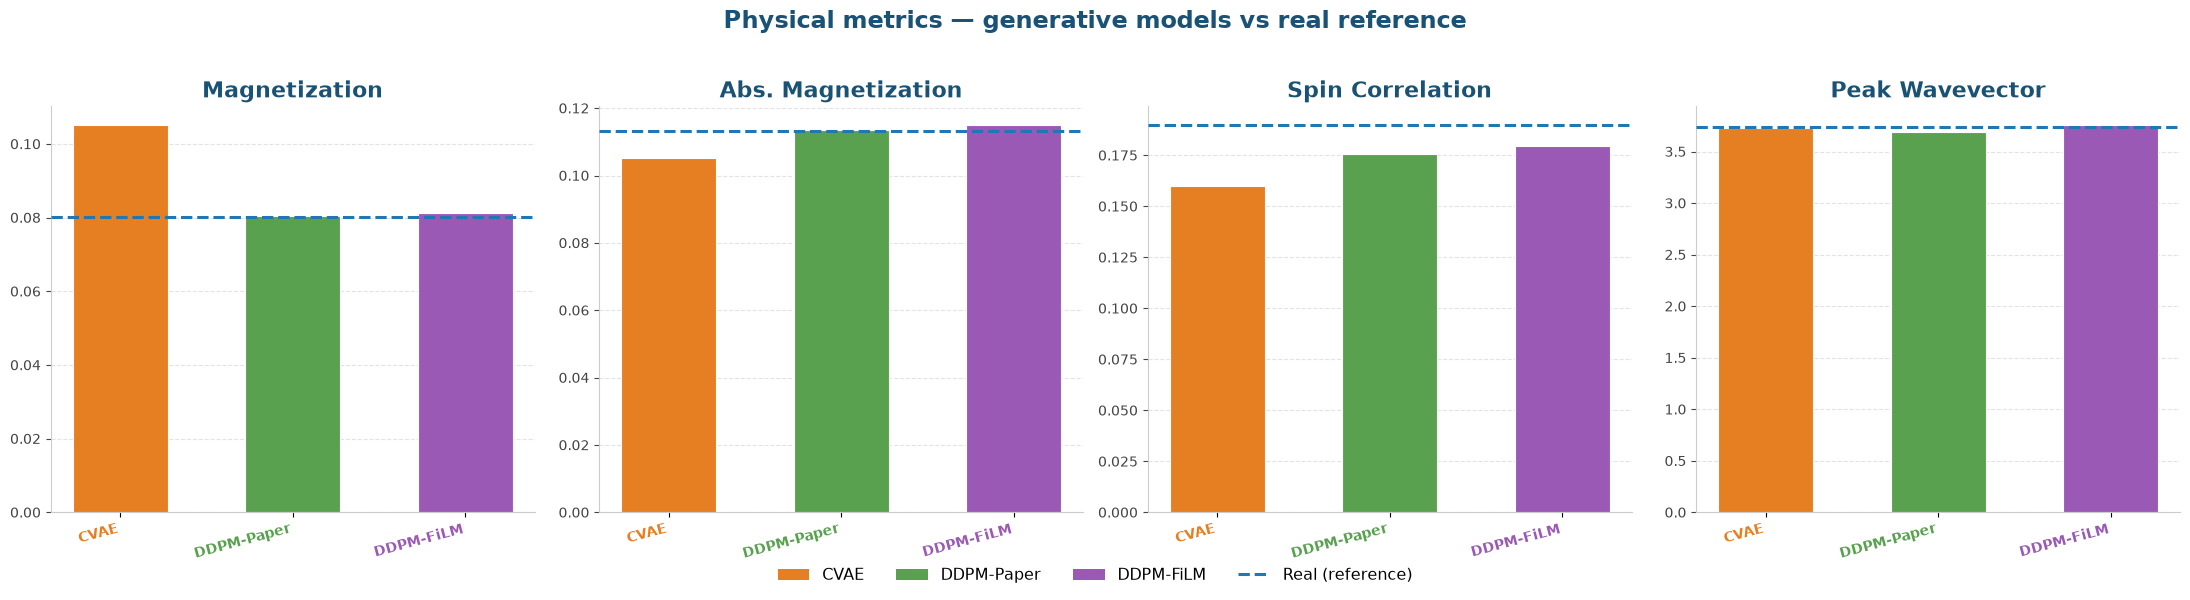

✅ generative_metrics_global_bars.pdf


In [14]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

sources_models = list(MODELS)

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), facecolor="white")

for ci, mt in enumerate(METRICS):
    ax = axes[ci]
    real_mean = np.concatenate([vals[mt]["Real"][s] for s in structures]).mean()
    means = [np.concatenate([vals[mt][m][s] for s in structures]).mean()
             for m in sources_models]
    xpos = np.arange(len(sources_models))
    ax.bar(xpos, means, width=0.55,
           color=[model_colors[m] for m in sources_models],
           edgecolor="white", linewidth=0.8, zorder=3)
    ax.axhline(real_mean, color="#1f77b4", linewidth=2.2, linestyle="--", zorder=4)
    ax.set_xticks(xpos)
    ax.set_xticklabels(sources_models, fontsize=FS_TICK*0.65, rotation=15, ha="right")
    for tick, m in zip(ax.get_xticklabels(), sources_models):
        tick.set_color(model_colors[m]); tick.set_fontweight("bold")
    ax.set_title(mt, fontsize=FS_TITLE*0.8, fontweight="bold", color=c_line)
    ax.tick_params(axis="y", labelsize=FS_TICK*0.65, colors="#444")
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color("#cccccc"); ax.spines["bottom"].set_color("#cccccc")

# UNA sola leyenda para toda la figura, abajo
legend_handles = [Patch(facecolor=model_colors[m], label=m) for m in sources_models] + \
                 [Line2D([0], [0], color="#1f77b4", linewidth=2.2, linestyle="--",
                         label="Real (reference)")]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           fontsize=FS_STATS*0.85, frameon=False, bbox_to_anchor=(0.5, -0.04))

plt.suptitle("Physical metrics — generative models vs real reference",
             fontsize=FS_TITLE*0.9, fontweight="bold", color=c_line, y=1.03)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/generative_metrics_global_bars.pdf", bbox_inches="tight", facecolor="white")
plt.show()
print("✅ generative_metrics_global_bars.pdf")

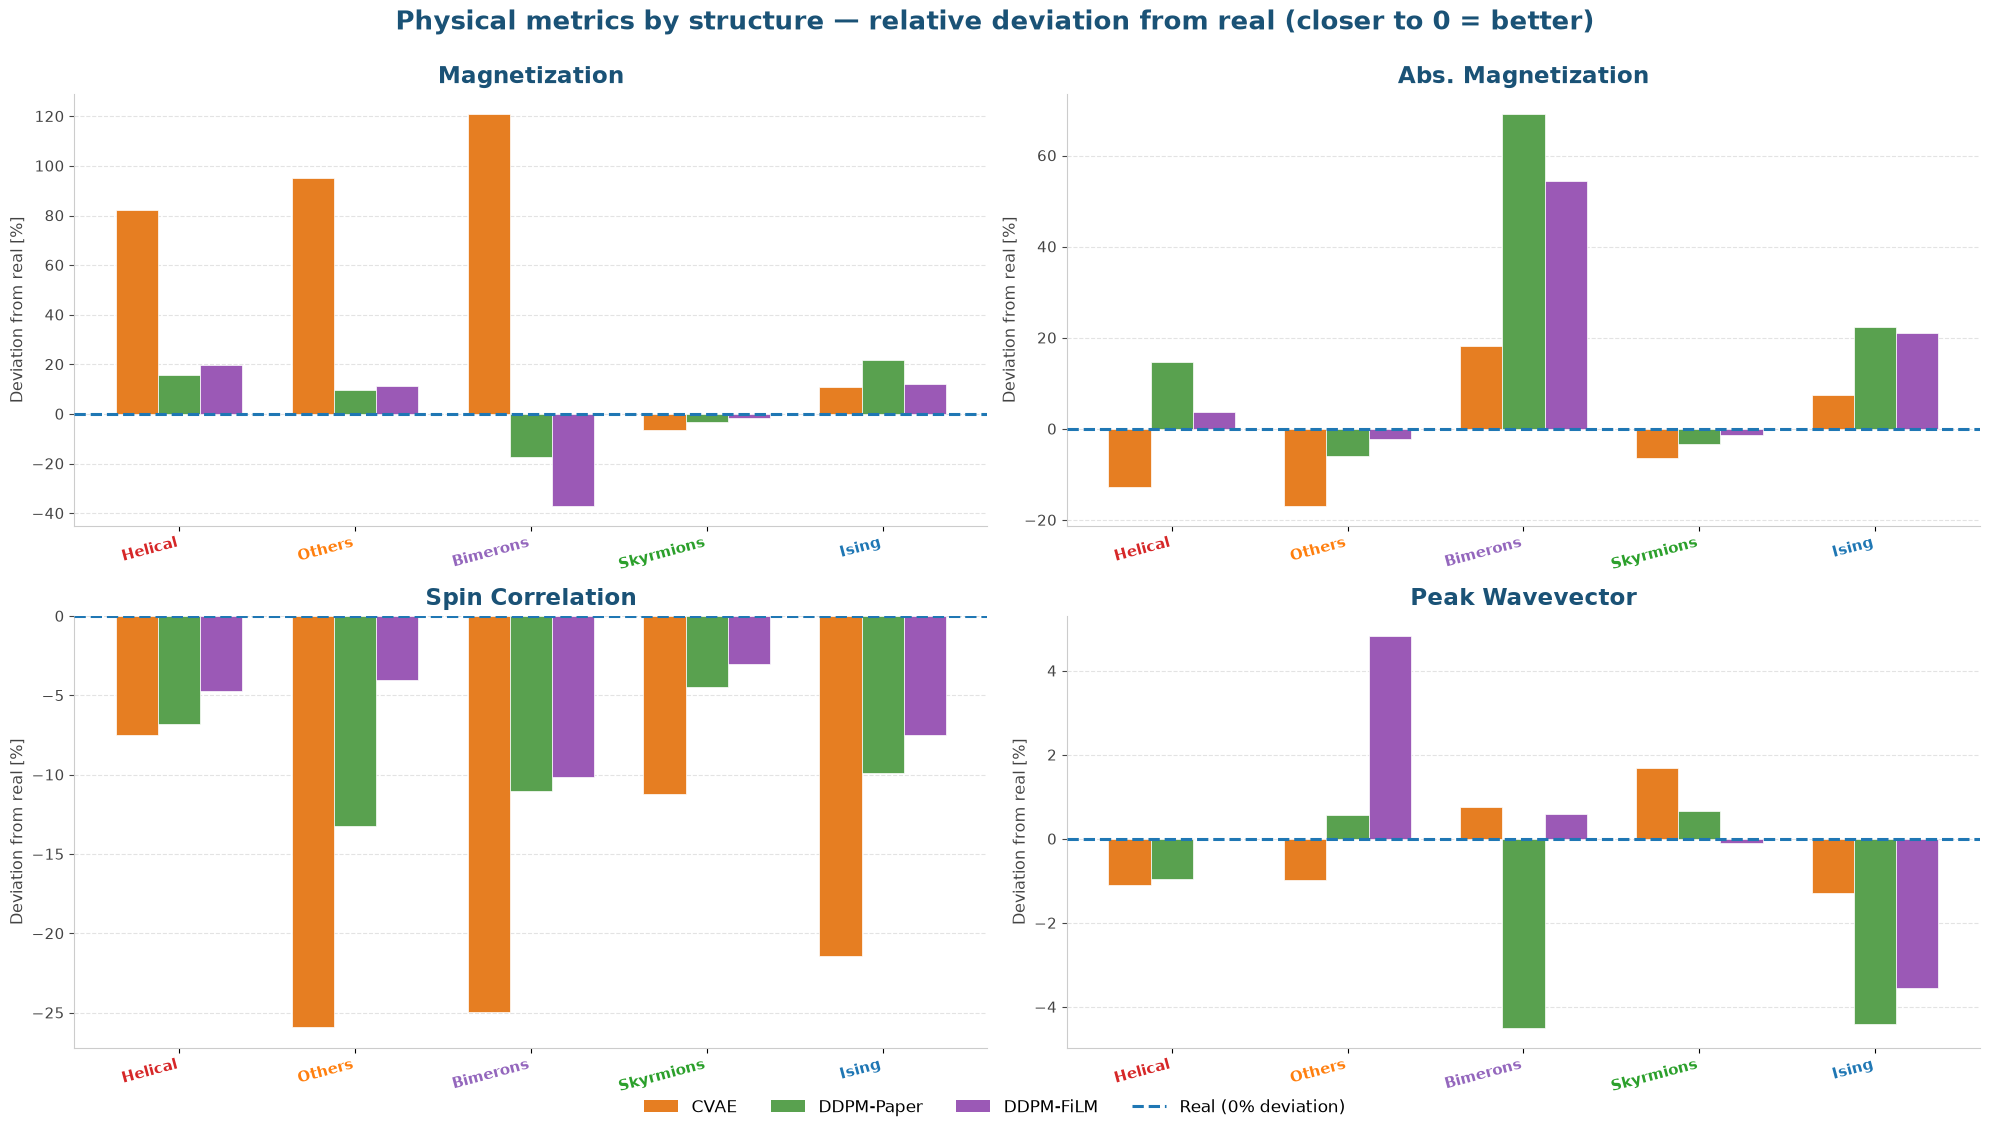

✅ generative_metrics_by_structure_bars.pdf


In [16]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

x_str = np.arange(len(structures)); bar_w = 0.24
sources_models = list(MODELS)

fig, axes = plt.subplots(2, 2, figsize=(20, 11), facecolor="white")
axes = axes.flatten()

for ci, mt in enumerate(METRICS):
    ax = axes[ci]
    for m_i, m in enumerate(sources_models):
        devs = []
        for s in structures:
            real_m = vals[mt]["Real"][s].mean()
            gen_m  = vals[mt][m][s].mean()
            # desviación relativa (%) respecto al real; escala robusta si real ~ 0
            denom = max(abs(real_m), np.abs(vals[mt]["Real"][s]).mean(), 1e-8)
            devs.append(100.0 * (gen_m - real_m) / denom)
        offset = (m_i - len(sources_models)/2 + 0.5) * bar_w
        ax.bar(x_str + offset, devs, width=bar_w,
               color=model_colors[m], edgecolor="white", linewidth=0.5, zorder=3)

    # línea de cero = coincidencia perfecta con el real
    ax.axhline(0, color="#1f77b4", linewidth=2.2, linestyle="--", zorder=4)

    ax.set_xticks(x_str)
    ax.set_xticklabels([structure_labels[s] for s in structures],
                       fontsize=FS_TICK*0.7, rotation=15, ha="right", fontweight="bold")
    for tick, s in zip(ax.get_xticklabels(), structures):
        tick.set_color(structure_colors[s])
    ax.set_title(mt, fontsize=FS_TITLE*0.85, fontweight="bold", color=c_line, pad=8)
    ax.set_ylabel("Deviation from real [%]", fontsize=FS_LABEL*0.7, color="#444")
    ax.tick_params(axis="y", labelsize=FS_TICK*0.7, colors="#444")
    ax.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines["left"].set_color("#cccccc"); ax.spines["bottom"].set_color("#cccccc")

legend_handles = [Patch(facecolor=model_colors[m], label=m) for m in sources_models] + \
                 [Line2D([0], [0], color="#1f77b4", linewidth=2.2, linestyle="--",
                         label="Real (0% deviation)")]
fig.legend(handles=legend_handles, loc="lower center", ncol=4,
           fontsize=FS_STATS*0.9, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Physical metrics by structure — relative deviation from real "
             "(closer to 0 = better)",
             fontsize=FS_TITLE*0.95, fontweight="bold", color=c_line, y=1.00)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/generative_metrics_by_structure_bars.pdf",
            bbox_inches="tight", facecolor="white")
plt.show()
print("✅ generative_metrics_by_structure_bars.pdf")